In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [88]:
cash_rate=pd.read_csv('data/2025-12-31/cash_rate.csv')
prices  = pd.read_csv('data/2025-12-31/prices.csv')
signals = pd.read_csv('data/2025-12-31/signals.csv')
volumes = pd.read_csv('data/2025-12-31/volumes.csv')

#2909	2025-02-28
norm_values = [ 589.84, 507.66, 81.29, 43.07, 91.24, 95.56, 263.98, 76.37, 84483.15, 2240.80 ]
prices.iloc[:, 1:] = prices.iloc[:, 1:].div(norm_values, axis=1)

prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3216 entries, 0 to 3215
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           3216 non-null   object 
 1   INSTRUMENT_1   3216 non-null   float64
 2   INSTRUMENT_2   3216 non-null   float64
 3   INSTRUMENT_3   3216 non-null   float64
 4   INSTRUMENT_4   3216 non-null   float64
 5   INSTRUMENT_5   3216 non-null   float64
 6   INSTRUMENT_6   3216 non-null   float64
 7   INSTRUMENT_7   3216 non-null   float64
 8   INSTRUMENT_8   3216 non-null   float64
 9   INSTRUMENT_9   3216 non-null   float64
 10  INSTRUMENT_10  3216 non-null   float64
dtypes: float64(10), object(1)
memory usage: 276.5+ KB


In [89]:
cash_rate.tail()

,date,1mo,1.5month,2mo,3mo,4mo,6mo,1yr,2yr,3yr,5yr,7yr,10yr,20yr,30yr
9001,2025-12-24,3.72,3.73,3.74,3.69,3.67,3.59,3.50,3.47,3.56,3.70,3.91,4.15,4.75,4.79
9002,2025-12-26,3.70,3.69,3.72,3.64,3.66,3.58,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81
9003,2025-12-29,3.69,3.70,3.70,3.68,3.66,3.59,3.48,3.45,3.51,3.67,3.88,4.12,4.75,4.80
9004,2025-12-30,3.65,3.71,3.65,3.65,3.63,3.59,3.47,3.45,3.50,3.68,3.89,4.14,4.76,4.81
9005,2025-12-31,3.74,3.75,3.67,3.67,3.63,3.59,3.48,3.47,3.55,3.73,3.94,4.18,4.79,4.84


In [90]:
prices.tail()

,date,INSTRUMENT_1,INSTRUMENT_2,INSTRUMENT_3,INSTRUMENT_4,INSTRUMENT_5,INSTRUMENT_6,INSTRUMENT_7,INSTRUMENT_8,INSTRUMENT_9,INSTRUMENT_10
3211,2025-12-27,1.166571,1.231848,1.184525,1.266311,0.962736,1.012034,1.582658,0.909650,1.044050,1.323228
3212,2025-12-28,1.166571,1.231907,1.184648,1.266543,0.962626,1.012034,1.582620,0.909781,1.044878,1.324116
3213,2025-12-29,1.162451,1.225899,1.181203,1.263292,0.966243,1.013499,1.513751,0.924709,1.036369,1.318734
3214,2025-12-30,1.160976,1.223043,1.183171,1.268400,0.963941,1.012558,1.514812,0.926542,1.051283,1.334747
3215,2025-12-31,1.152431,1.212938,1.178128,1.264453,0.956160,1.009104,1.505152,0.918816,1.041258,1.333948


In [91]:
signals.head(32)

,date,INSTRUMENT_1_trend4,INSTRUMENT_1_trend8,INSTRUMENT_1_trend16,INSTRUMENT_1_trend32,INSTRUMENT_2_trend4,INSTRUMENT_2_trend8,INSTRUMENT_2_trend16,INSTRUMENT_2_trend32,INSTRUMENT_3_trend4,...,INSTRUMENT_8_trend16,INSTRUMENT_8_trend32,INSTRUMENT_9_trend4,INSTRUMENT_9_trend8,INSTRUMENT_9_trend16,INSTRUMENT_9_trend32,INSTRUMENT_10_trend4,INSTRUMENT_10_trend8,INSTRUMENT_10_trend16,INSTRUMENT_10_trend32
0,2017-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017-01-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017-01-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017-01-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
volumes.tail()
prices.columns

Index(['date', 'INSTRUMENT_1', 'INSTRUMENT_2', 'INSTRUMENT_3', 'INSTRUMENT_4',
       'INSTRUMENT_5', 'INSTRUMENT_6', 'INSTRUMENT_7', 'INSTRUMENT_8',
       'INSTRUMENT_9', 'INSTRUMENT_10'],
      dtype='object')

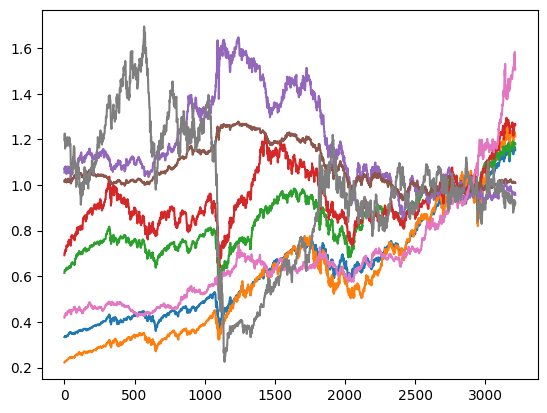

In [93]:
for instrument in prices.columns[1:]:
    if instrument != "INSTRUMENT_9" and instrument != "INSTRUMENT_10":
        instrument_price=prices[instrument]
        plt.plot(instrument_price)
    else:
        pass


plt.show()

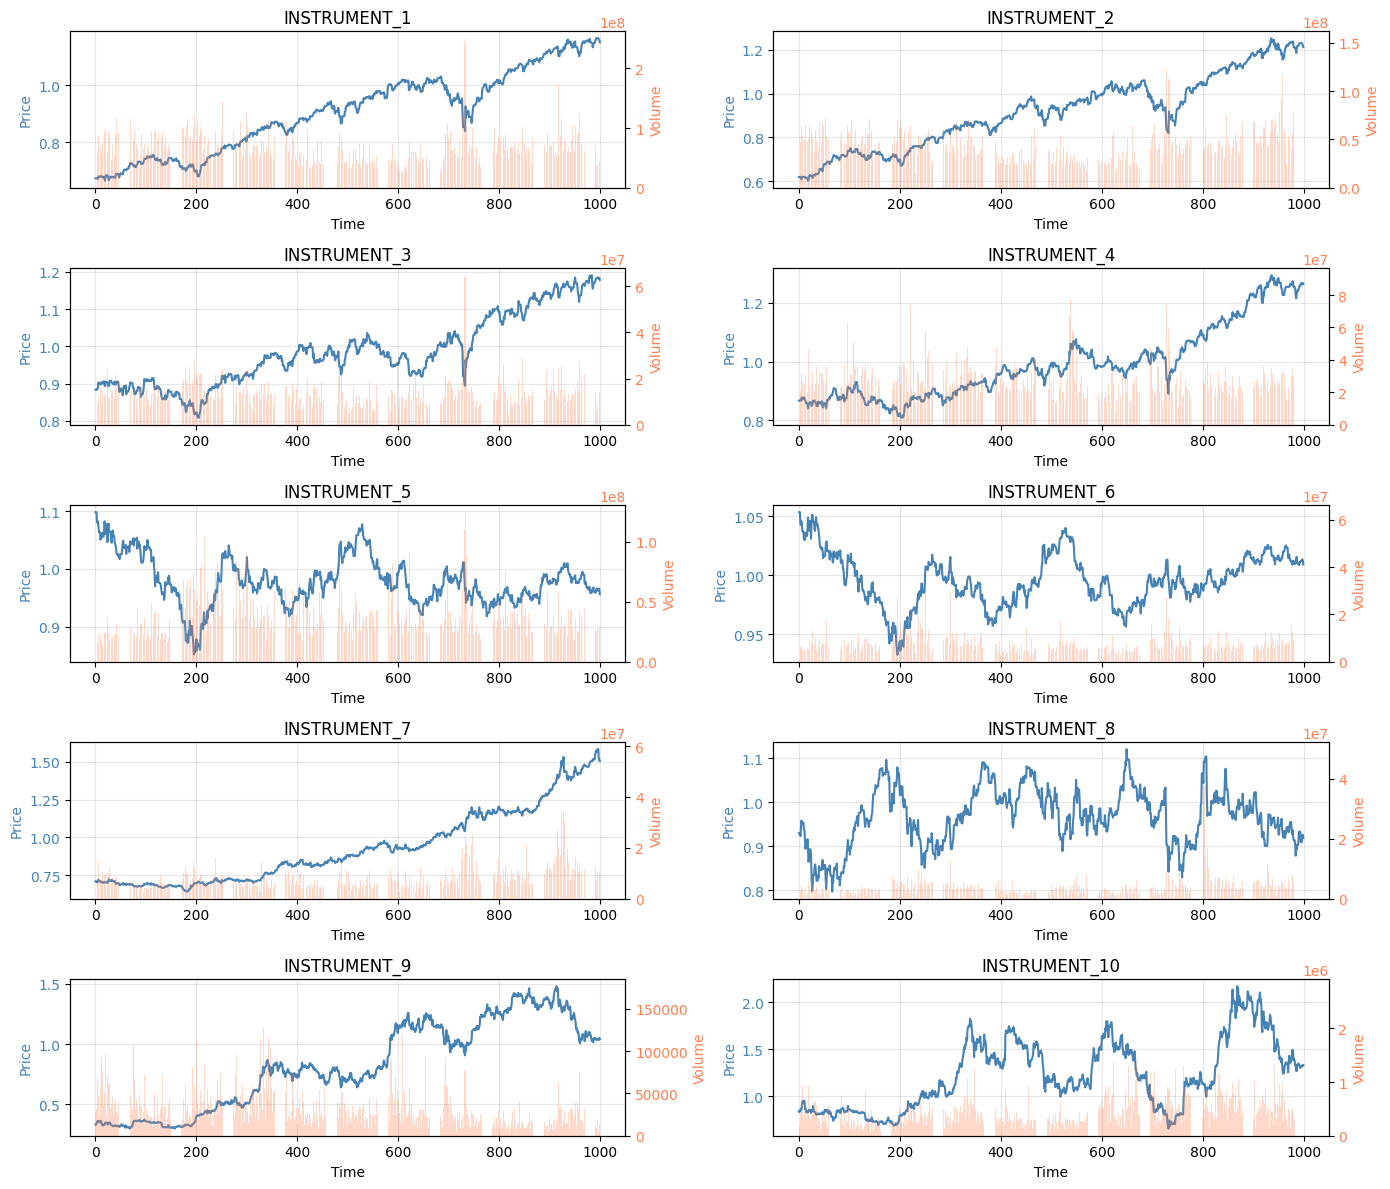

In [94]:
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, instrument in enumerate(prices.columns[1:]):
    ax1 = axes[idx]
    ax2 = ax1.twinx()
    
    # Plot price on left axis (last 1000 rows)
    ax1.plot(prices[instrument].iloc[-1000:].values, color='steelblue', label='Price')
    ax1.set_ylabel('Price', color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    
    # Plot volume on right axis (last 1000 rows)
    vol_col = f'{instrument}_vol'
    ax2.bar(range(1000), volumes[vol_col].iloc[-1000:].values, alpha=0.3, color='coral', label='Volume')
    ax2.set_ylabel('Volume', color='coral')
    ax2.tick_params(axis='y', labelcolor='coral')
    
    ax1.set_title(f'{instrument}')
    ax1.set_xlabel('Time')
    ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


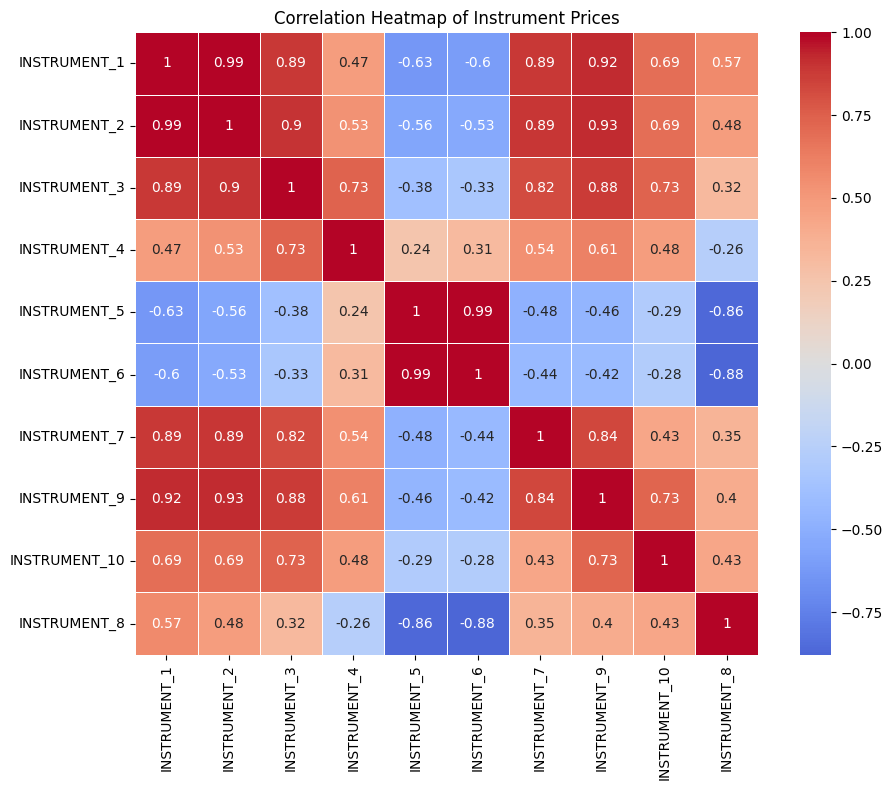

In [95]:
p = prices[[f"INSTRUMENT_{i}" for i in [1,2,3,4,5,6,7,9,10,8]]]
corr = p.iloc[1200:].corr(numeric_only=True)
#mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center = 0, square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Instrument Prices')
plt.tight_layout()
plt.show()

In [96]:
from itertools import combinations

# Generate all combinations of 3 assets with weights >= 0 and sum = 1.0
# Using increments of 0.01
instruments = [f"INSTRUMENT_{i}" for i in [1, 2, 3, 4, 5, 6, 7, 9, 10, 8]]

# Create weight combinations (in increments of 0.01, so using integers 0-100)
N = 10
weight_combinations = []
for w1 in range(N+1):
    for w2 in range(N+1 - w1):
        for w3 in range(N+1 - w1 - w2):
            w4 = N - w1 - w2 - w3
            weight_combinations.append([w1 / N, w2 / N, w3 / N, w4 / N])

# Create all combinations of 3 assets with their weights
portfolio_combinations = []
for asset_combo in combinations(instruments, 4):
    for weights in weight_combinations:
        portfolio_combinations.append({
            'assets': asset_combo,
            'weights': weights
        })

print(f"Total portfolio combinations: {len(portfolio_combinations)}")
print(f"Sample: {portfolio_combinations[0]}")



Total portfolio combinations: 60060
Sample: {'assets': ('INSTRUMENT_1', 'INSTRUMENT_2', 'INSTRUMENT_3', 'INSTRUMENT_4'), 'weights': [0.0, 0.0, 0.0, 1.0]}


In [97]:
# Slice the price data to the desired time period
ps = p.iloc[-1000:]

# Calculate daily returns
returns = ps.pct_change().dropna()

# Pre-compute mean returns and covariance matrix for speed
mean_returns = returns.mean()
cov_matrix = returns.cov()

results = []

for combo in portfolio_combinations:
    assets = list(combo['assets'])
    weights = np.array(combo['weights'])

    # Portfolio return and volatility
    port_return = np.dot(weights, mean_returns[assets])
    port_volatility = np.sqrt(weights @ cov_matrix.loc[assets, assets].values @ weights)

    sharpe = port_return / port_volatility if port_volatility != 0 else np.nan

    results.append({
        'assets': assets,
        'weights': weights.tolist(),
        'sharpe': sharpe
    })

# Sort by Sharpe ratio descending
results.sort(key=lambda x: x['sharpe'] if not np.isnan(x['sharpe']) else -np.inf, reverse=True)

print(f"Best portfolio Sharpe: {results[0]['sharpe']:.4f}")
print(f"Assets: {results[0]['assets']}")
print(f"Weights: {results[0]['weights']}")

Best portfolio Sharpe: 0.1179
Assets: ['INSTRUMENT_1', 'INSTRUMENT_2', 'INSTRUMENT_7', 'INSTRUMENT_9']
Weights: [0.1, 0.2, 0.6, 0.1]


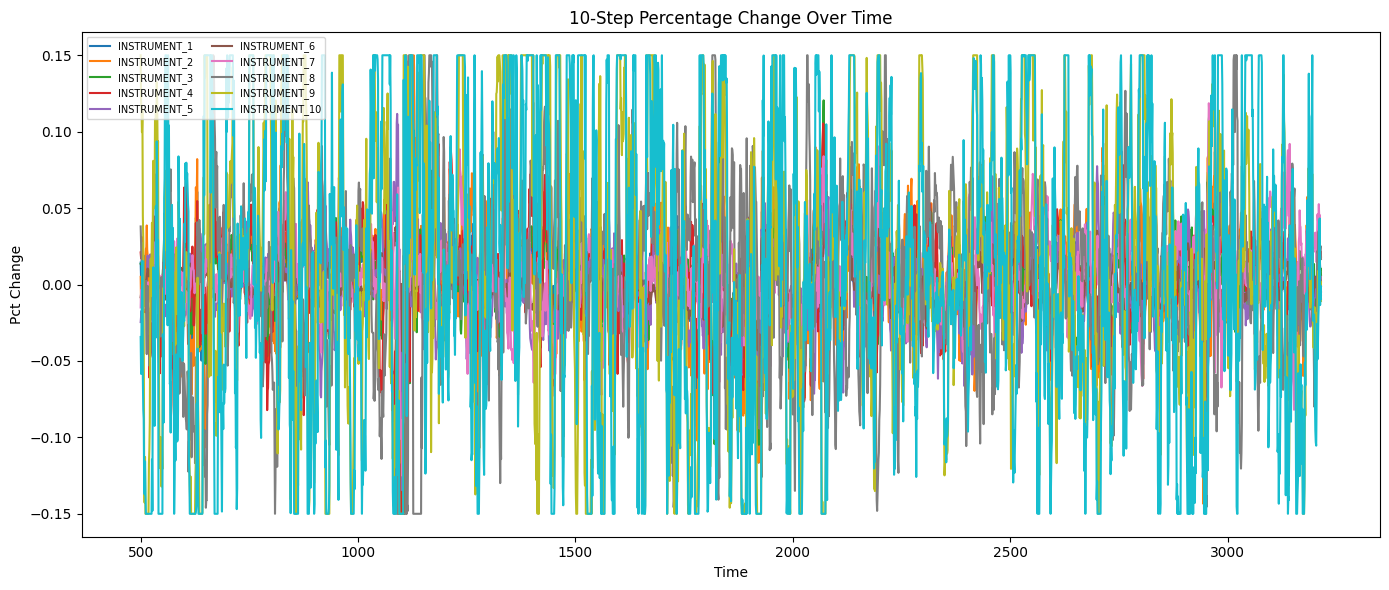

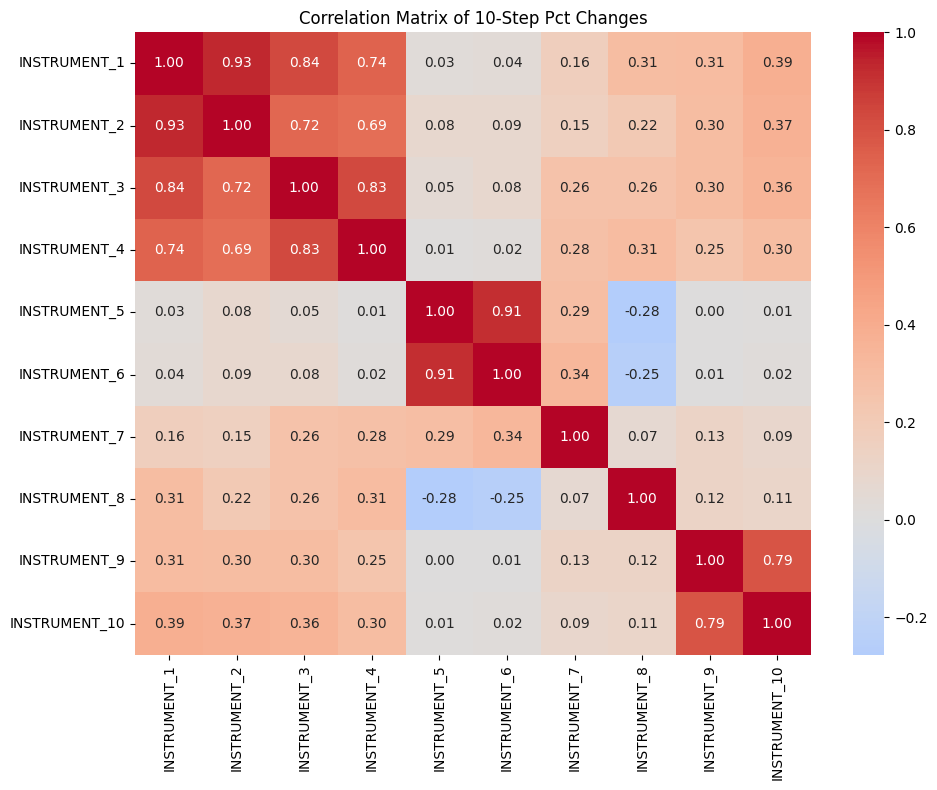

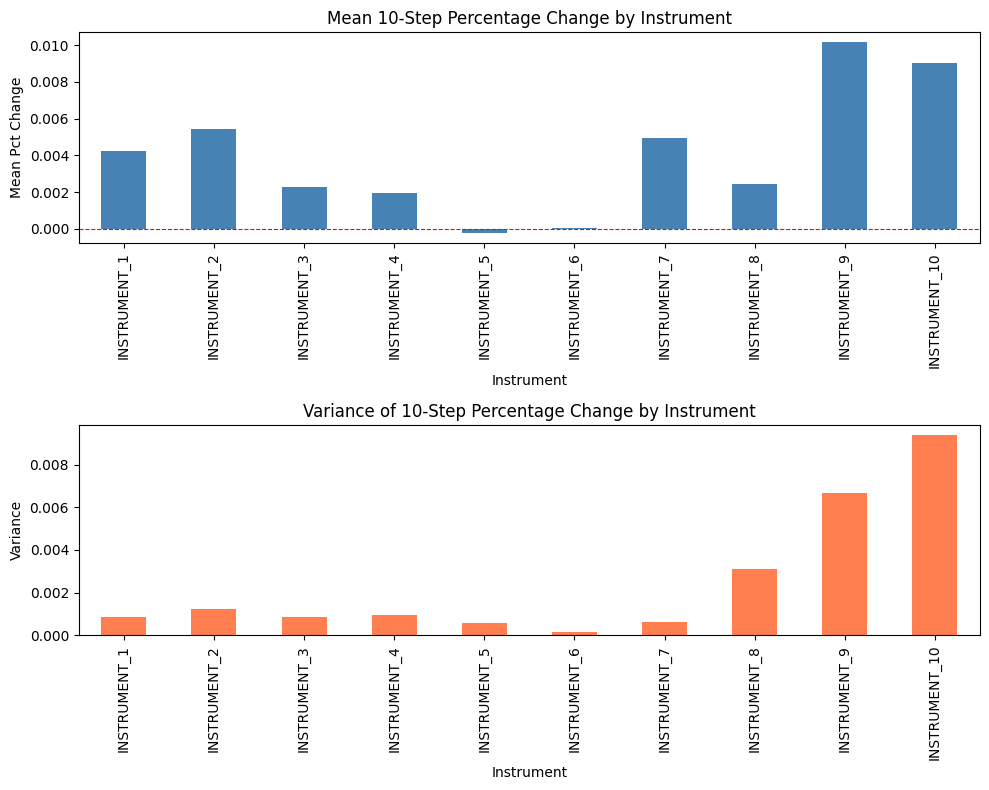

In [98]:
#dprice = prices.diff(10).fillna(0).clip()
dprice = prices.select_dtypes(include='number').pct_change(10).fillna(0).clip(-0.15, 0.15)[500:]

# import matplotlib.pyplot as plt
# import seaborn as sns

# --- Percentage changes over time ---
fig, ax = plt.subplots(figsize=(14, 6))
dprice.plot(ax=ax)
ax.set_title("10-Step Percentage Change Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Pct Change")
ax.legend(loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# --- Correlation matrix ---
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dprice.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix of 10-Step Pct Changes")
plt.tight_layout()
plt.show()

# Plot means and variances of dprice
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot means
dprice.mean().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title("Mean 10-Step Percentage Change by Instrument")
ax1.set_xlabel("Instrument")
ax1.set_ylabel("Mean Pct Change")
ax1.axhline(y=0, color='red', linestyle='--', linewidth=0.8)

# Plot variances
dprice.var().plot(kind='bar', ax=ax2, color='coral')
ax2.set_title("Variance of 10-Step Percentage Change by Instrument")
ax2.set_xlabel("Instrument")
ax2.set_ylabel("Variance")

plt.tight_layout()
plt.show()

In [99]:
# First, let's create merged_df by merging prices, signals, and volumes on date
merged_df = prices[['date']].copy()

# # Add price columns (excluding date)
# for col in prices.columns[1:]:
#     merged_df[col] = prices[col]

# Merge signals (excluding date column)
for col in signals.columns[1:]:
    merged_df[col] = signals[col]

# Merge volumes (excluding date column)
for col in volumes.columns[1:]:
    merged_df[col] = volumes[col]

# Calculate dprice (10-step percentage change) for target variables
dprice_cols = [f"dprice_{col}" for col in prices.columns[1:]]
for col in prices.columns[1:]:
    merged_df[f"dprice_{col}"] = prices[col].pct_change(10).fillna(0).clip(-0.3, 0.3)

# Remove rows with NaN values
merged_df = merged_df.dropna()[-700:]

print(f"Merged dataframe shape: {merged_df.shape}")

Merged dataframe shape: (700, 61)


In [100]:
from lightgbm import LGBMRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

feature_cols = [c for c in merged_df.columns if c != "date" and not c.startswith("dprice_")]
target_cols = [c for c in merged_df.columns if c.startswith("dprice_")]

X = merged_df[feature_cols].shift(1)
y = merged_df[target_cols]

X = X.iloc[1:].replace([np.inf, -np.inf], np.nan).fillna(0)
y = y.iloc[1:].replace([np.inf, -np.inf], np.nan).fillna(0)

n = len(X)
min_train = int(n * 0.5)
step = int(n * 0.05)

all_preds = []
all_actuals = []

lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        verbose=-1
    )
)

for train_end in range(min_train, n, step):
    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]
    X_test  = X.iloc[train_end:train_end + step]
    y_test  = y.iloc[train_end:train_end + step]

    if len(X_test) == 0:
        break

    lgbm.fit(X_train, y_train)

    all_preds.append(lgbm.predict(X_test))
    all_actuals.append(y_test.values)

y_pred_all = np.vstack(all_preds)
y_test_all = np.vstack(all_actuals)

overall_rmse = np.sqrt(mean_squared_error(y_test_all, y_pred_all))
overall_r2   = r2_score(y_test_all, y_pred_all, multioutput="uniform_average")

print(f"Overall RMSE: {overall_rmse:.6f}")
print(f"Overall R²:   {overall_r2:.6f}")

metrics_df = pd.DataFrame({
    "target": target_cols,
    "rmse": [np.sqrt(mean_squared_error(y_test_all[:, i], y_pred_all[:, i])) for i in range(len(target_cols))],
    "r2":   [r2_score(y_test_all[:, i], y_pred_all[:, i]) for i in range(len(target_cols))],
}).sort_values("r2", ascending=False)

metrics_df

Overall RMSE: 0.047268
Overall R²:   0.006017


,target,rmse,r2
9,dprice_INSTRUMENT_10,0.108959,0.139438
6,dprice_INSTRUMENT_7,0.026103,0.120291
1,dprice_INSTRUMENT_2,0.032372,0.090907
7,dprice_INSTRUMENT_8,0.049303,0.045375
2,dprice_INSTRUMENT_3,0.026285,0.006508
8,dprice_INSTRUMENT_9,0.059884,0.006098
0,dprice_INSTRUMENT_1,0.026922,-0.001297
4,dprice_INSTRUMENT_5,0.018123,-0.031398
5,dprice_INSTRUMENT_6,0.008359,-0.041931
3,dprice_INSTRUMENT_4,0.030168,-0.273820


                  feature  importance
38  INSTRUMENT_10_trend16        39.2
22   INSTRUMENT_6_trend16        37.5
5     INSTRUMENT_2_trend8        37.4
48       INSTRUMENT_9_vol        36.8
1     INSTRUMENT_1_trend8        33.9
3    INSTRUMENT_1_trend32        33.9
16    INSTRUMENT_5_trend4        33.0
23   INSTRUMENT_6_trend32        30.9
4     INSTRUMENT_2_trend4        30.5
2    INSTRUMENT_1_trend16        30.2
0     INSTRUMENT_1_trend4        29.1
49      INSTRUMENT_10_vol        27.8
46       INSTRUMENT_7_vol        22.4
41       INSTRUMENT_2_vol        16.5
44       INSTRUMENT_5_vol        15.6
47       INSTRUMENT_8_vol        12.1
45       INSTRUMENT_6_vol        10.5
43       INSTRUMENT_4_vol        10.2
42       INSTRUMENT_3_vol         9.8
40       INSTRUMENT_1_vol         9.5


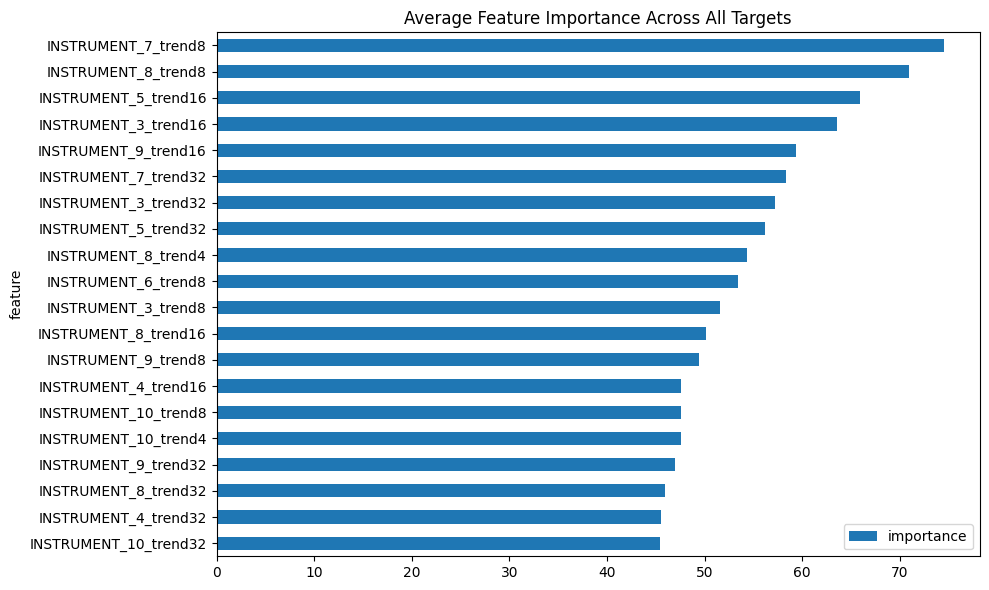

In [101]:
import matplotlib.pyplot as plt

# Extract feature importances from each sub-estimator and average
importances = np.mean(
    [est.feature_importances_ for est in lgbm.estimators_],
    axis=0
)

feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feat_imp.tail(20))

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(20).plot.barh(x='feature', y='importance', ax=ax)
ax.invert_yaxis()
ax.set_title("Average Feature Importance Across All Targets")
plt.tight_layout()
plt.show()

In [102]:
for i, (est, col) in enumerate(zip(lgbm.estimators_, target_cols)):
    fi = pd.Series(est.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"\nTop 5 features for {col}:")
    print(fi.head())


Top 5 features for dprice_INSTRUMENT_1:
INSTRUMENT_3_trend16    107
INSTRUMENT_8_trend4      91
INSTRUMENT_7_trend8      90
INSTRUMENT_8_trend8      86
INSTRUMENT_5_trend16     77
dtype: int32

Top 5 features for dprice_INSTRUMENT_2:
INSTRUMENT_7_trend8     95
INSTRUMENT_3_trend16    91
INSTRUMENT_8_trend8     89
INSTRUMENT_5_trend16    75
INSTRUMENT_4_trend16    70
dtype: int32

Top 5 features for dprice_INSTRUMENT_3:
INSTRUMENT_7_trend8     98
INSTRUMENT_5_trend16    96
INSTRUMENT_3_trend32    82
INSTRUMENT_8_trend4     79
INSTRUMENT_3_trend8     78
dtype: int32

Top 5 features for dprice_INSTRUMENT_4:
INSTRUMENT_4_trend32    95
INSTRUMENT_4_trend16    93
INSTRUMENT_7_trend8     91
INSTRUMENT_3_trend16    83
INSTRUMENT_8_trend8     81
dtype: int32

Top 5 features for dprice_INSTRUMENT_5:
INSTRUMENT_6_trend8     104
INSTRUMENT_5_trend8      91
INSTRUMENT_9_trend16     87
INSTRUMENT_9_trend32     84
INSTRUMENT_5_trend16     73
dtype: int32

Top 5 features for dprice_INSTRUMENT_6:
INST

dprice_INSTRUMENT_10    0.064116
dprice_INSTRUMENT_9     0.029878
dprice_INSTRUMENT_2     0.021815
dprice_INSTRUMENT_7     0.021585
dprice_INSTRUMENT_4     0.017676
dprice_INSTRUMENT_1     0.013786
dprice_INSTRUMENT_3     0.009410
dprice_INSTRUMENT_5     0.004900
dprice_INSTRUMENT_6     0.002685
dprice_INSTRUMENT_8    -0.017852
dtype: float64


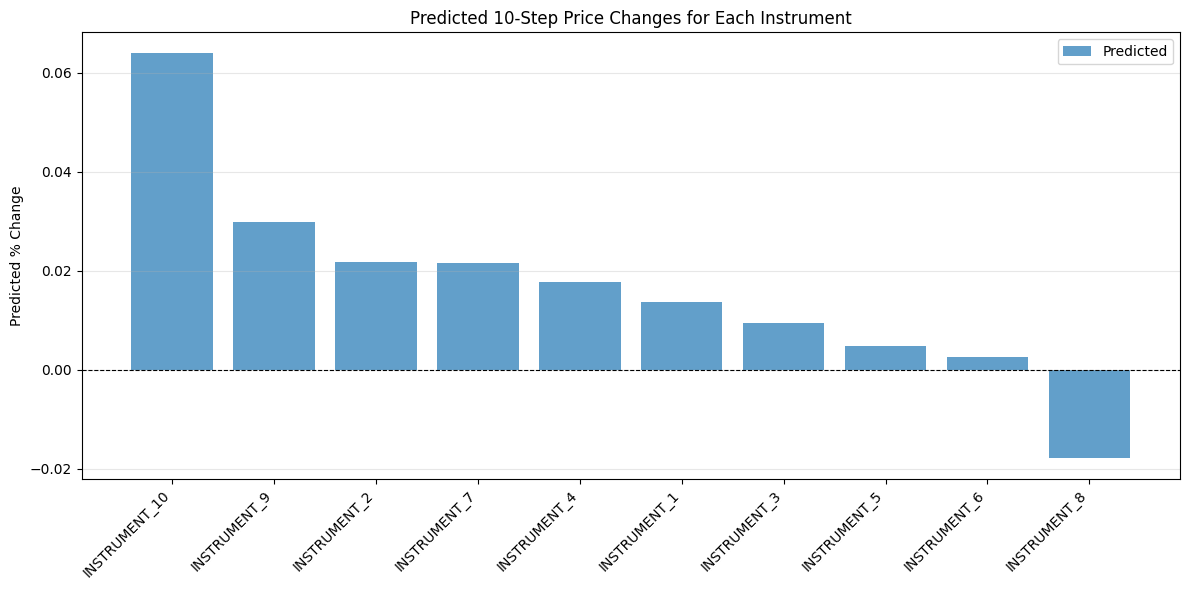

In [103]:
# Get the most recent row of features (already lagged, so this is safe to use)
X_latest = X.iloc[[-1]]  # keep as DataFrame to preserve column names

predicted_pct_change = lgbm.predict(X_latest)[0]

predictions = pd.Series(predicted_pct_change, index=target_cols).sort_values(ascending=False)
print(predictions)

# Plot predicted vs actual percentage changes
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(predictions))
ax.bar(x_pos, predictions.values, alpha=0.7, label='Predicted')
ax.set_xticks(x_pos)
ax.set_xticklabels([col.replace('dprice_', '') for col in predictions.index], rotation=45, ha='right')
ax.set_ylabel('Predicted % Change')
ax.set_title('Predicted 10-Step Price Changes for Each Instrument')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

PC1 Explained Variance Ratio: 0.6392

PC1 Weights:
      Instrument  PC1_Weight
9  INSTRUMENT_10    0.803183
8   INSTRUMENT_9    0.560144
1   INSTRUMENT_2    0.125619
0   INSTRUMENT_1    0.104305
2   INSTRUMENT_3    0.086934
3   INSTRUMENT_4    0.080991
7   INSTRUMENT_8    0.017149
4   INSTRUMENT_5    0.002486
5   INSTRUMENT_6   -0.002029
6   INSTRUMENT_7   -0.007397


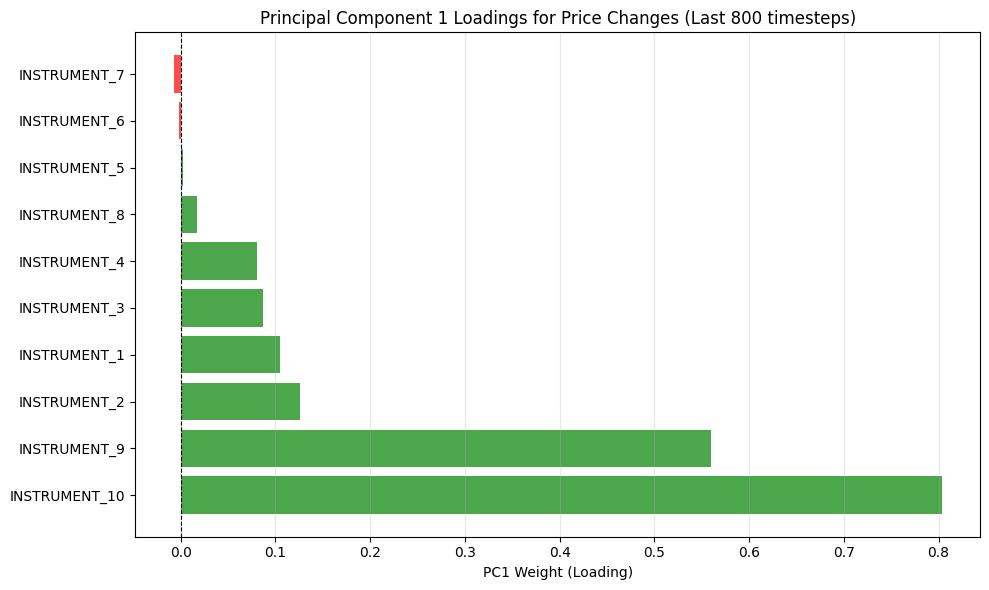

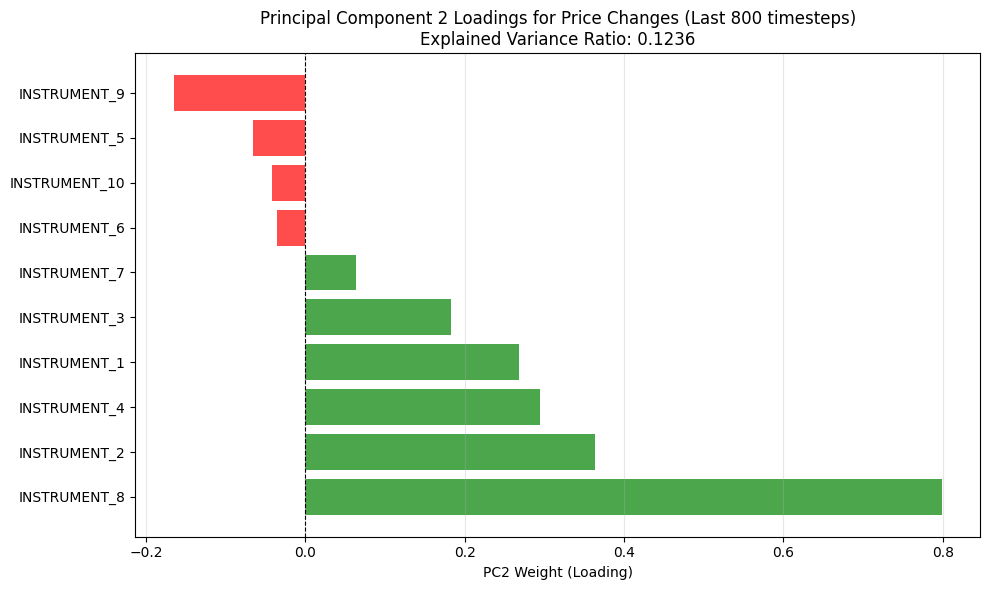

In [104]:
from sklearn.decomposition import PCA

# Get the last 800 timesteps of dprice
dprice_recent = dprice.iloc[-800:]

# Apply PCA
pca = PCA()
pca.fit(dprice_recent)

# Get PC1 loadings (weights)
pc1_weights = pca.components_[0]

# Create a DataFrame for visualization
pc1_df = pd.DataFrame({
    'Instrument': [col.replace('dprice_', '') for col in dprice_recent.columns],
    'PC1_Weight': pc1_weights
}).sort_values('PC1_Weight', ascending=False)

print(f"PC1 Explained Variance Ratio: {pca.explained_variance_ratio_[0]:.4f}")
print("\nPC1 Weights:")
print(pc1_df)

# Plot PC1 weights
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in pc1_df['PC1_Weight']]
ax.barh(pc1_df['Instrument'], pc1_df['PC1_Weight'], color=colors, alpha=0.7)
ax.set_xlabel('PC1 Weight (Loading)')
ax.set_title('Principal Component 1 Loadings for Price Changes (Last 800 timesteps)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot PC2 weights
fig, ax = plt.subplots(figsize=(10, 6))
pc2_weights = pca.components_[1]
pc2_df = pd.DataFrame({
    'Instrument': [col.replace('dprice_', '') for col in dprice_recent.columns],
    'PC2_Weight': pc2_weights
}).sort_values('PC2_Weight', ascending=False)

colors = ['green' if x > 0 else 'red' for x in pc2_df['PC2_Weight']]
ax.barh(pc2_df['Instrument'], pc2_df['PC2_Weight'], color=colors, alpha=0.7)
ax.set_xlabel('PC2 Weight (Loading)')
ax.set_title(f'Principal Component 2 Loadings for Price Changes (Last 800 timesteps)\nExplained Variance Ratio: {pca.explained_variance_ratio_[1]:.4f}')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [116]:
import yfinance as yf

p = prices.set_index("date") if "date" in prices.columns else prices.copy()
p.index = pd.to_datetime(p.index)

candidates = [
    # US mega cap tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "ORCL", "CRM", "ADBE",
    "INTC", "AMD", "QCOM", "TXN", "AMAT", "MU", "AVGO", "NFLX", "UBER", "LYFT",
    "SNOW", "PLTR", "NET", "DDOG", "ZS", "CRWD", "OKTA", "MDB", "SHOP",
    "PYPL", "COIN", "HOOD", "RBLX", "U", "TWLO", "ZM", "DOCN", "IOT",

    # Financials
    "JPM", "BAC", "GS", "MS", "WFC", "C", "BLK", "AXP", "V", "MA",
    "COF", "SCHW", "BX", "KKR", "CB", "ICE", "CME", "SPGI", "MCO", "PGR",
    "TRV", "AFL", "MET", "PRU", "AIG", "USB", "PNC", "TFC", "FITB", "MTB",

    # Healthcare
    "JNJ", "PFE", "UNH", "ABBV", "MRK", "LLY", "BMY", "AMGN", "GILD", "CVS",
    "TMO", "ABT", "MDT", "SYK", "BSX", "ISRG", "REGN", "VRTX", "BIIB", "MRNA",
    "ZBH", "BAX", "BDX", "IQV", "CNC", "HUM", "CI", "ELV", "DVA", "HOLX",

    # Energy
    "XOM", "CVX", "COP", "SLB", "EOG", "MPC", "PSX", "VLO", "OXY", "BP",
    "HAL", "BKR", "FANG", "APA", "DVN", "CTRA", "KMI",
    "WMB", "OKE", "LNG", "ET", "EPD",

    # Consumer / Retail
    "WMT", "KO", "PG", "PEP", "COST", "TGT", "MCD", "SBUX", "NKE", "DIS",
    "HD", "LOW", "TJX", "BKNG", "MAR", "HLT", "YUM", "CMG", "DPZ",
    "EL", "CL", "CHD", "GIS", "CPB", "HSY", "MKC", "SJM", "CAG",

    # Industrials
    "BA", "CAT", "GE", "MMM", "HON", "LMT", "RTX", "UPS", "FDX", "DE",
    "NOC", "GD", "TDG", "HII", "EMR", "ETN", "PH", "ROK", "AME",
    "XYL", "GNRC", "CARR", "OTIS", "IR", "TT", "JCI", "ALLE", "RRX", "AOS",

    # Materials
    "LIN", "APD", "SHW", "ECL", "DD", "DOW", "NEM", "FCX", "NUE", "STLD",
    "ALB", "MOS", "CF", "VMC", "MLM", "PKG", "IP", "SEE", "SON",

    # Real Estate
    "AMT", "PLD", "CCI", "EQIX", "PSA", "EQR", "AVB", "ARE", "BXP",
    "VTR", "WELL", "HR", "MPW", "SPG", "O", "VICI", "GLPI", "SBAC",

    # International
    "TSM", "ASML", "SAP", "NVO", "SONY", "TM", "HMC", "BABA", "JD", "PDD",
    "SE", "GRAB", "MELI", "NU", "ITUB", "BBD", "VALE", "RIO", "BHP",

    # ETFs / Indices / Sectors
    "SPY", "QQQ", "IWM", "DIA", "GLD", "SLV", "TLT", "HYG", "USO", "UNG",
    "VNQ", "EEM", "EFA", "XLE", "XLF", "XLK", "XLV", "ARKK", "XLI", "XLB",
    "XLU", "XLP", "XLY", "XLRE", "XLC", "SOXX", "IBB", "XBI", "KRE", "IAT",
    "ICLN", "JETS", "HACK", "BUZZ", "BOTZ", "ROBO", "AIQ", "SKYY", "CLOU", "FINX",

    # Crypto
    "BTC-USD", "ETH-USD", "SOL-USD", "BNB-USD", "XRP-USD", "ADA-USD",
    "AVAX-USD", "DOGE-USD", "LINK-USD", "DOT-USD", "MATIC-USD", "LTC-USD",
    "UNI-USD", "ATOM-USD", "XLM-USD", "ALGO-USD", "FIL-USD", "VET-USD",
    "SAND-USD", "MANA-USD",

    # Futures proxies
    "GC=F",   # Gold
    "SI=F",   # Silver
    "CL=F",   # Crude Oil
    "NG=F",   # Natural Gas
    "ZW=F",   # Wheat
    "ZC=F",   # Corn
    "ZS=F",   # Soybeans
    "HG=F",   # Copper
    "PL=F",   # Platinum
    "PA=F",   # Palladium
    "LE=F",   # Live Cattle
    "HE=F",   # Lean Hogs
    "KC=F",   # Coffee
    "CT=F",   # Cotton
    "SB=F",   # Sugar

    # FX
    "EURUSD=X", "GBPUSD=X", "JPYUSD=X", "AUDUSD=X", "CADUSD=X",
    "CHFUSD=X", "NZDUSD=X", "CNYUSD=X", "HKDUSD=X", "SGDUSD=X",
    "MXNUSD=X", "BRLUSD=X", "INRUSD=X", "KRWUSD=X", "SEKUSD=X",
]

real_prices = yf.download(candidates, period="max", auto_adjust=True, multi_level_index=False)["Close"]
real_prices.index = pd.to_datetime(real_prices.index)

# Drop columns that completely failed to download
real_prices = real_prices.dropna(axis=1, how="all")

common_dates = p.index.intersection(real_prices.index)
print(f"Overlapping dates: {len(common_dates)} ({common_dates[0]} → {common_dates[-1]})")

p_aligned = p.loc[common_dates].select_dtypes(include='number')
r_aligned = real_prices.loc[common_dates]

p_returns = p_aligned.pct_change(fill_method=None).dropna()
r_returns = r_aligned.pct_change(fill_method=None).dropna()

common_dates = p_returns.index.intersection(r_returns.index)
p_returns = p_returns.loc[common_dates]
r_returns = r_returns.loc[common_dates]

matches = {}
for instrument in p_returns.columns:
    correlations = r_returns.corrwith(p_returns[instrument]).sort_values(ascending=False)
    matches[instrument] = correlations.head(5)

for instrument, top5 in matches.items():
    print(f"\n{instrument}:")
    for ticker, corr in top5.items():
        print(f"  {ticker}: {corr:.4f}")

[*********************100%***********************]  323 of 323 completed


Overlapping dates: 3216 (2017-01-03 00:00:00 → 2025-12-31 00:00:00)

INSTRUMENT_1:
  SPY: 1.0000
  QQQ: 0.9557
  XLK: 0.9307
  DIA: 0.9257
  XLY: 0.9037

INSTRUMENT_2:
  QQQ: 1.0000
  XLK: 0.9728
  SPY: 0.9558
  AIQ: 0.9473
  XLY: 0.9016

INSTRUMENT_3:
  EFA: 0.9937
  ROBO: 0.8728
  BOTZ: 0.8311
  EEM: 0.8096
  SPY: 0.8035

INSTRUMENT_4:
  EEM: 0.9999
  EFA: 0.8152
  AIQ: 0.7784
  ROBO: 0.7741
  JD: 0.7489

INSTRUMENT_5:
  TLT: 0.9999
  HYG: 0.4049
  AMT: 0.3470
  GLD: 0.3413
  SBAC: 0.3371

INSTRUMENT_6:
  TLT: 0.9111
  HYG: 0.4616
  GLD: 0.4449
  AMT: 0.3752
  SBAC: 0.3721

INSTRUMENT_7:
  GLD: 1.0000
  GC=F: 0.8927
  SLV: 0.7984
  SI=F: 0.7024
  NEM: 0.6365

INSTRUMENT_8:
  USO: 1.0000
  CL=F: 0.9572
  XLE: 0.6385
  XOM: 0.6256
  COP: 0.6051

INSTRUMENT_9:
  BTC-USD: 0.9990
  ETH-USD: 0.8520
  SAND-USD: 0.7550
  SOL-USD: 0.7524
  DOT-USD: 0.7372

INSTRUMENT_10:
  ETH-USD: 0.9992
  BTC-USD: 0.8502
  MATIC-USD: 0.7906
  DOT-USD: 0.7655
  SAND-USD: 0.7577


In [122]:
from scipy.optimize import minimize

# --- Step 1: Map each instrument to its best matching real stock ---
# best_matches = {inst: matches[inst].index[0] for inst in matches}
best_matches = {inst: matches[inst].index[0] for inst in matches if inst != "INSTRUMENT_6"}
print("Instrument → Stock mapping:")
for inst, ticker in best_matches.items():
    print(f"  {inst} → {ticker} (corr: {matches[inst].iloc[0]:.4f})")

# --- Step 2: Use ALL available real stock returns up to today ---
tickers = list(best_matches.values())
real_returns = real_prices[tickers].pct_change(fill_method=None).dropna()  # no date filter!

print(f"Using data from {real_returns.index[0].date()} to {real_returns.index[-1].date()}")

ticker_to_inst = {v: k for k, v in best_matches.items()}
instrument_returns = real_returns.rename(columns=ticker_to_inst)

# --- Step 3: Sharpe ratio function ---
rf = cash_rate["3mo"].iloc[-1] / 100
mu_annual  = instrument_returns.mean() * 252
cov_matrix = instrument_returns.cov().values * 252

def sharpe(weights):
    weights = np.array(weights)
    ret = np.dot(weights, mu_annual)
    vol = np.sqrt(weights @ cov_matrix @ weights)
    return (ret - rf) / vol if vol > 0 else 0

# --- Step 4: Optimise ---
n = len(best_matches)

result = minimize(
    lambda w: -sharpe(w),
    x0=np.ones(n) / n,
    method="SLSQP",
    bounds=[(0, 1)] * n,
    constraints={"type": "eq", "fun": lambda w: w.sum() - 1},
    options={"maxiter": 1000}
)

optimal_weights = pd.Series(result.x, index=list(best_matches.keys())).sort_values(ascending=False)
port_return = np.dot(result.x, mu_annual)
port_vol    = np.sqrt(result.x @ cov_matrix @ result.x)

print(f"\nOptimised Portfolio:")
print(f"  Expected Annual Return: {port_return:.2%}")
print(f"  Expected Volatility:    {port_vol:.2%}")
print(f"  Sharpe Ratio:           {sharpe(result.x):.4f}")
print(f"\nWeights:")
print(optimal_weights[optimal_weights > 0.000001].apply(lambda x: f"{x:.2%}"))

Instrument → Stock mapping:
  INSTRUMENT_1 → SPY (corr: 1.0000)
  INSTRUMENT_2 → QQQ (corr: 1.0000)
  INSTRUMENT_3 → EFA (corr: 0.9937)
  INSTRUMENT_4 → EEM (corr: 0.9999)
  INSTRUMENT_5 → TLT (corr: 0.9999)
  INSTRUMENT_7 → GLD (corr: 1.0000)
  INSTRUMENT_8 → USO (corr: 1.0000)
  INSTRUMENT_9 → BTC-USD (corr: 0.9990)
  INSTRUMENT_10 → ETH-USD (corr: 0.9992)
Using data from 2017-11-10 to 2026-02-27

Optimised Portfolio:
  Expected Annual Return: 16.29%
  Expected Volatility:    11.58%
  Sharpe Ratio:           1.0902

Weights:
INSTRUMENT_7    46.40%
INSTRUMENT_1    28.37%
INSTRUMENT_5    17.37%
INSTRUMENT_9     4.98%
INSTRUMENT_8     2.88%
dtype: object
